In [1]:
from typing import Dict, TypedDict
from langgraph.graph import StateGraph

## 1. Base Graph ( accepting single input)

In [ ]:
# We now create an AgentState - shared data structure that keeps track of information as your application runs. 

class AgentState(TypedDict): # Our state schema
    message : str 


def greeting_node(state: AgentState) -> AgentState:
    """Simple node that adds a greeting message to the state"""

    state['message'] =  state["message"] + ", You are doing an amzing job learing langgraph!"

    return state 


In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeter", greeting_node)


graph.set_entry_point("greeter")

graph.set_finish_point("greeter")

app = graph.compile()

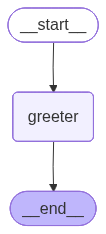

In [17]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [27]:
result = app.invoke({"message": "Bob"})

In [28]:
result["message"]

'Bob, You are doing an amzing job learing langgraph!'

## 02. Adding  Multiple Inputs


In [30]:
from typing import TypedDict, List
from langgraph.graph import StateGraph 

In [31]:
class AgentState(TypedDict):
    values: List[int]
    name: str 
    result: str 

In [32]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)

    state["result"] = f"Hi there {state["name"]}! Your sum = {sum(state["values"])}"

    print(state)
    return state

In [33]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor") # Set the starting node
graph.set_finish_point("processor") # Set the ending node

app = graph.compile() # Compiling the graph

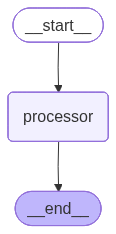

In [34]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [35]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve"})

{'values': [1, 2, 3, 4], 'name': 'Steve'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}


In [36]:
print(answers)
print(answers["result"])

{'values': [1, 2, 3, 4], 'name': 'Steve', 'result': 'Hi there Steve! Your sum = 10'}
Hi there Steve! Your sum = 10


### exersice

In [37]:
class AgentState(TypedDict):
    values: List[int]
    name: str 
    operation: str
    result: str 

In [38]:
def process_values(state: AgentState) -> AgentState:
    """This function handles multiple different inputs"""
    print(state)
    if state["operation"] == "+":
        state["result"] = f"Hi there {state["name"]}! Your sum = {sum(state["values"])}"
    if state["operation"] == "*":
        
        product = 1
        for v in state["values"]:
            product *= v 
        state["result"] = f"Hi there {state["name"]}! Your product = {product}"

    print(state)
    return state

In [39]:
graph = StateGraph(AgentState)

graph.add_node("processor", process_values)
graph.set_entry_point("processor") # Set the starting node
graph.set_finish_point("processor") # Set the ending node

app = graph.compile()

In [40]:
answers = app.invoke({"values": [1,2,3,4], "name": "Steve", "operation": "*"})

{'values': [1, 2, 3, 4], 'name': 'Steve', 'operation': '*'}
{'values': [1, 2, 3, 4], 'name': 'Steve', 'operation': '*', 'result': 'Hi there Steve! Your product = 24'}


In [41]:
print(answers["result"])

Hi there Steve! Your product = 24


## 03. Sequential Grpah!!

In [42]:
class AgentState(TypedDict):
    name: str
    age: str
    final: str

In [43]:
def first_node(state:AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state["final"] = f"Hi {state["name"]}!"
    return state

def second_node(state:AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state["final"] = state["final"] + f" You are {state["age"]} years old!"

    return state

In [44]:
graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.set_finish_point("second_node")
app = graph.compile()

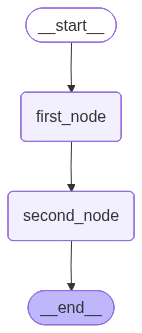

In [45]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [46]:
result = app.invoke({"name": "Charlie", "age": 20})
print(result)

{'name': 'Charlie', 'age': 20, 'final': 'Hi Charlie! You are 20 years old!'}


### 3.1 Exercise

In [48]:
from typing import TypedDict # Imports all the data types we need
from langgraph.graph import StateGraph


class AgentState(TypedDict):
    name: str
    age: str
    skills: List[str]
    final: str

def first_node(state:AgentState) -> AgentState:
    """This is the first node of our sequence"""

    state["final"] = f"Hi {state["name"]}!"
    return state

def second_node(state:AgentState) -> AgentState:
    """This is the second node of our sequence"""

    state["final"] = state["final"] + f" You are {state["age"]} years old!"

    return state

def third_node(state:AgentState) -> AgentState:
    """This is the third node of our sequence"""

    state["final"] = state["final"] + f" Your skills are {', '.join(state["skills"])}!"

    return state

graph = StateGraph(AgentState)

graph.add_node("first_node", first_node)
graph.add_node("second_node", second_node)
graph.add_node("third_node", third_node)

graph.set_entry_point("first_node")
graph.add_edge("first_node", "second_node")
graph.add_edge("second_node", "third_node")
graph.set_finish_point("third_node")
app = graph.compile()

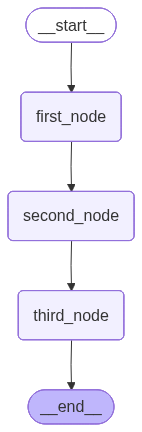

In [51]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [49]:
result = app.invoke({"name": "Charlie", "age": 20, "skills": ["Python", "LangGraph"]})
print(result)

{'name': 'Charlie', 'age': 20, 'skills': ['Python', 'LangGraph'], 'final': 'Hi Charlie! You are 20 years old! Your skills are Python, LangGraph!'}


In [50]:
print(result["final"])

Hi Charlie! You are 20 years old! Your skills are Python, LangGraph!


## 4.0  Conditional Graph

In [52]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

In [53]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    finalNumber: int

In [54]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "subtraction_operation" 

In [55]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("router", lambda state:state) # passthrough function

graph.add_edge(START, "router") 

graph.add_conditional_edges(
    "router",
    decide_next_node, 

    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }

)

graph.add_edge("add_node", END)
graph.add_edge("subtract_node", END)

app = graph.compile()

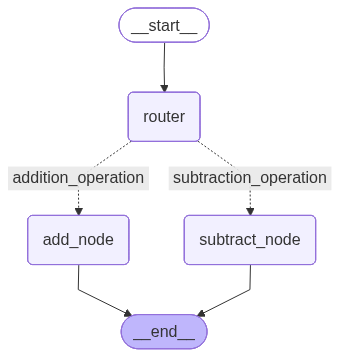

In [56]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [57]:
initial_state_1 = AgentState(number1 = 10, operation="-", number2 = 5)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


In [58]:
# This way still works!

result = app.invoke({"number1": 10, "operation": "-", "number2": 5})
print(result)

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5}


### 4.1 exercise

In [ ]:
class AgentState(TypedDict):
    number1: int 
    operation: str 
    number2: int
    finalNumber: int
    number3: int
    number4: int
    operation2: str
    finalNumber2: int

In [111]:
def adder(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber"] = state["number1"] + state["number2"]

    return state

def subtractor(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber"] = state["number1"] - state["number2"]
    return state


def adder2(state:AgentState) -> AgentState:
    """This node adds the 2 numbers"""
    state["finalNumber2"] = state["number3"] + state["number4"]

    return state

def subtractor2(state:AgentState) -> AgentState:
    """This node subtracts the 2 numbers"""
    state["finalNumber2"] = state["number3"] - state["number4"]
    return state


def decide_next_node(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation"] == "+":
        return "addition_operation"
    
    elif state["operation"] == "-":
        return "subtraction_operation" 

def decide_next_node_2(state:AgentState) -> AgentState:
    """This node will select the next node of the graph"""

    if state["operation2"] == "+":
        return "addition_operation2"
    
    elif state["operation2"] == "-":
        return "subtraction_operation2" 





In [112]:
graph = StateGraph(AgentState)

graph.add_node("add_node", adder)
graph.add_node("subtract_node", subtractor)
graph.add_node("add_node2", adder2)
graph.add_node("subtract_node2", subtractor2)
graph.add_node("router", lambda state:state) # passthrough function
graph.add_node("router2", lambda state:state)
graph.add_edge(START, "router") 

graph.add_conditional_edges(
    "router",
    decide_next_node, 

    {
        # Edge: Node
        "addition_operation": "add_node",
        "subtraction_operation": "subtract_node"
    }

)

graph.add_conditional_edges(
    "router2",
    decide_next_node_2, 

    {
        # Edge: Node
        "addition_operation2": "add_node2",
        "subtraction_operation2": "subtract_node2"
    }

)

graph.add_edge("add_node","router2") 
graph.add_edge("subtract_node", "router2")

graph.add_edge("add_node2", END)
graph.add_edge("subtract_node2", END)



app = graph.compile()

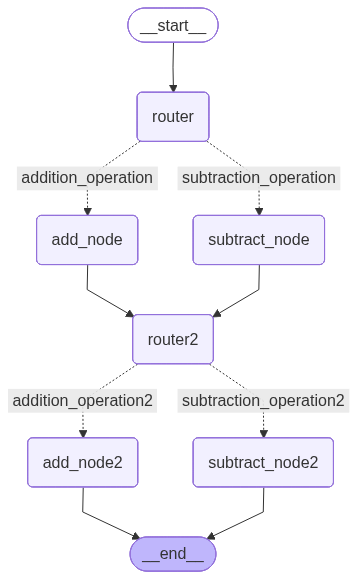

In [106]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [113]:
initial_state_1 = AgentState(number1 = 10, operation="-", number2 = 5, number3 = 7,number4 = 3, operation2 = "+",finalNumber = 0,finalNumber2 = 0)
print(app.invoke(initial_state_1))

{'number1': 10, 'operation': '-', 'number2': 5, 'finalNumber': 5, 'number3': 7, 'number4': 3, 'operation2': '+', 'finalNumber2': 10}


## Looping Graph

In [114]:
from langgraph.graph import StateGraph, END
import random
from typing import Dict, List, TypedDict

In [115]:
class AgentState(TypedDict):
    name: str
    number: List[int]
    counter: int

In [116]:
def greeting_node(state: AgentState) -> AgentState:
    """Greeting Node which says hi to the person"""
    state["name"] = f"Hi there, {state["name"]}"
    state["counter"] = 0 

    return state

def random_node(state: AgentState) -> AgentState:
    """Generates a random number from 0 to 10"""
    state["number"].append(random.randint(0, 10))
    state["counter"] += 1

    return state


def should_continue(state: AgentState) -> AgentState:
    """Function to decide what to do next"""
    if state["counter"] < 5:
        print("ENTERING LOOP", state["counter"])
        return "loop"  # Continue looping
    else:
        return "exit"  # Exit the loop

In [117]:
graph = StateGraph(AgentState)

graph.add_node("greeting", greeting_node)
graph.add_node("random", random_node)
graph.add_edge("greeting", "random")


graph.add_conditional_edges(
    "random",     # Source node
    should_continue, # Action
    {
        "loop": "random",  
        "exit": END          
    }
)

graph.set_entry_point("greeting")

app = graph.compile()

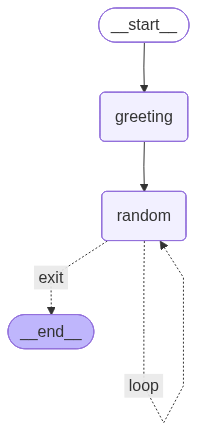

In [118]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [120]:
app.invoke({"name":"Ben", "number":[], "counter":-100})

ENTERING LOOP 1
ENTERING LOOP 2
ENTERING LOOP 3
ENTERING LOOP 4


{'name': 'Hi there, Ben', 'number': [7, 7, 7, 5, 2], 'counter': 5}